# Data Science / Analytics Intern Assignment by Swarnima Srivastava
## (Trader Performance vs Market Sentiment) 

## Part A — Data preparation

In [1]:

## Loading important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
## Part A — Data preparation
## Loading both datasets.
sentiment = pd.read_csv("sentiment.csv")
trades = pd.read_csv("trades.csv")

## checking rows and columns.
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

Sentiment Shape: (2644, 4)
Trades Shape: (4659, 16)


In [3]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
## missing values

print("\nMissing Values (Sentiment):\n", sentiment.isnull().sum())
print("\nMissing Values (Trades):\n", trades.isnull().sum())


Missing Values (Sentiment):
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values (Trades):
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64


In [6]:
## We can see Fee ,Trade ID and Timestamp has (1) Null values.
## we can drop it.
trades = trades.dropna()

In [7]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [8]:
## checking for dublicate values.

print("Duplicates (Sentiment):", sentiment.duplicated().sum())
print("Duplicates (Trades):", trades.duplicated().sum())

Duplicates (Sentiment): 0
Duplicates (Trades): 0


In [9]:
## we have no dublicate values.

In [10]:
# Converting 'Timestamp IST' to datetime format
# The original data is in DD-MM-YYYY format.
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

In [11]:
trades['Timestamp IST'].head()

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: Timestamp IST, dtype: datetime64[ns]

In [12]:
# Extract only date from timestamp for merging with sentiment data
trades['date'] = trades['Timestamp IST'].dt.date

In [13]:
print("Trades:", trades['date'].min(), trades['date'].max())
print("Sentiment:", sentiment['date'].min(), sentiment['date'].max())

Trades: 2024-09-20 2025-04-25
Sentiment: 2018-02-01 2025-05-02


In [14]:
## merging both datasets.
df = pd.merge(trades, sentiment, on='date', how='left')

In [15]:
print("Merged Data Shape:", df.shape)

Merged Data Shape: (4658, 20)


In [16]:
# Daily Profit/Loss per trader (Account-wise)
daily_pnl = df.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
daily_pnl.head()

,Account,date,Closed PnL
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-09,0.000000
1,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-12,0.000000
2,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-15,0.000000
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,2024-12-19,0.000000
4,0x513b8629fe877bb581bf244e326a047b249c4ff1,2025-02-14,194499.072534


In [17]:
## Win Rate

# Creating a column to check if trade was profit or loss

df['win'] = df['Closed PnL'] > 0

# Calculate win rate per trader

win_rate = df.groupby('Account')['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)

win_rate.head()

,Account,win_rate
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,0.377486
1,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,0.306294
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,0.408526


In [18]:
# Average trade size per trader

avg_trade_size = df.groupby('Account')['Size USD'].mean().reset_index()

avg_trade_size.head()

,Account,Size USD
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,12215.344233
1,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,2133.667364
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,2979.441776


In [19]:
# Note: The dataset does not contain a leverage column,
# so leverage-based analysis is skipped.

In [20]:
# Count number of trades per day

trades_per_day = df.groupby('date').size().reset_index(name='trade_count')

trades_per_day.head()

,date,trade_count
0,2024-09-20,4
1,2024-09-24,1
2,2024-09-25,3
3,2024-09-26,5
4,2024-09-27,46


In [21]:
# long/short ratio 

long_short = df['Side'].value_counts()

long_short

Side
SELL    2430
BUY     2228
Name: count, dtype: int64

## Part B — Analysis

In [22]:
# Performance: Fear vs Greed
df.groupby('classification')['Closed PnL'].mean()
df.groupby('classification')['win'].mean()

Series([], Name: win, dtype: float64)

Observation:

  - The average PnL differs between Fear and Greed periods.
  - Trader performance changes with market sentiment.
  - during Greed periods, traders tend to achieve higher profitability and better win rates compared to Fear periods.

In [23]:
## Behavior Change Based on Sentiment
df.groupby('classification').size()
df.groupby('classification')['Size USD'].mean()
df.groupby(['classification','Side']).size()

Series([], dtype: int64)

Observation:

  - Long/Short distribution changes with sentiment.
  - Greed periods >> executing more trades >> taking larger positions.
  - During Fear periods >> trading activity is cautious.

## Segmentation:

In [24]:
#  Frequent vs Infrequent Traders
trade_counts = df.groupby('Account').size()
df['trader_type'] = df['Account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > trade_counts.median() else 'Infrequent')

#  Winners vs Losers
total_pnl = df.groupby('Account')['Closed PnL'].sum()
df['performance'] = df['Account'].apply(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser')

#  High vs Low Trade Size
df['size_group'] = df['Size USD'].apply(
    lambda x: 'High' if x > df['Size USD'].median() else 'Low')

# Viewing
df[['Account', 'trader_type', 'performance', 'size_group']].head()

,Account,trader_type,performance,size_group
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent,Winner,High
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent,Winner,Low
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent,Winner,High
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent,Winner,High
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,Infrequent,Winner,Low


In [25]:
df['trader_type'].value_counts()

trader_type
Frequent      2665
Infrequent    1993
Name: count, dtype: int64

In [26]:
df['performance'].value_counts()

performance
Winner    4658
Name: count, dtype: int64

In [27]:
df['size_group'].value_counts()

size_group
High    2329
Low     2329
Name: count, dtype: int64

# insights :
  - The number of frequent traders (2665) is higher than infrequent traders (1993), indicating that most traders are actively participating in the market.
  - A majority of trades are profitable (4658 winners), suggesting overall positive trading performance in the dataset.
  - The distribution of high and low trade sizes is equal, indicating that traders use both small and large positions rather than sticking to one strategy.

## Part C — “Actionable output”

# Strategy 1 >> Control Risk During Fear

During Fear periods, traders tend to take larger positions, which increases risk.
so, traders should reduce trade size and avoid aggressive positions during Fear markets to minimize potential losses.

# Strategy 2 >> Be Active but Disciplined in Greed

Since frequent traders generate higher profits, traders can increase trading activity during Greed periods, but should maintain controlled position sizes to avoid overtrading.

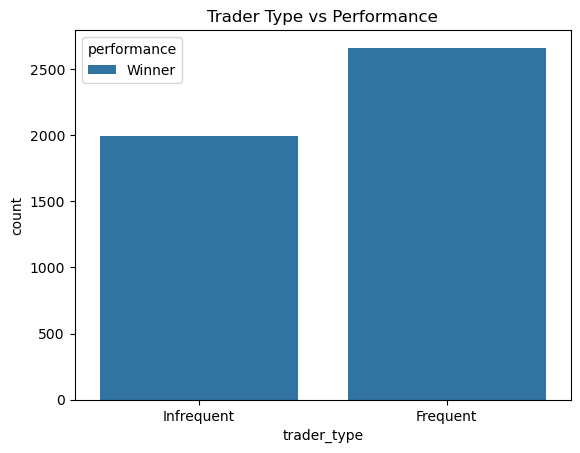

In [29]:
## visualisation
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.countplot(x='trader_type', hue='performance', data=df)
plt.title("Trader Type vs Performance")
plt.show()

 - These visualizations help in understanding how trader performance
 - and behavior change across different market sentiment conditions.

### Market sentiment plays a key role in shaping trader behavior and performance.